In [76]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy
from cycler import cycler
from scipy.integrate import trapezoid
palette = [
                "#E90E0E",  
                "#E79106",  
                "#F1E20E",  
                "#07D90ED9",  
                "#2A54DF",  
                "#583AA8",  
                "#9214EC",   
                "#EC1487"
                ]
plt.rcParams.update({
"axes.prop_cycle": cycler(color=palette)})

We can define a Voigt profile, which is a combination of a Gaussian (from Doppler broadening) and a Lorentzian (from natural/collisional broadening). 
$$H(a,u) = \frac{a}{\pi}\int_{-\infty}^{\infty} \frac{\exp{(-y^2)}dy}{a^2 + (u-y)^2}$$
$$a = \frac{\Gamma}{4\pi \Delta \nu_D}$$
$$u = \frac{\nu - \nu_0}{\Delta \nu_D}$$

In [77]:
def integrate_voigt_profile(a, u, ymin=-5, ymax=5, num_points=1000):
    """
    Numerically integrate the Voigt profile from [ymin, ymax].
    """
    y = np.linspace(ymin, ymax, num_points)
    z = a/np.pi * np.exp(-y**2)/(a**2 + (u-y)**2)
    integral_result = trapezoid(z, y)
    return integral_result

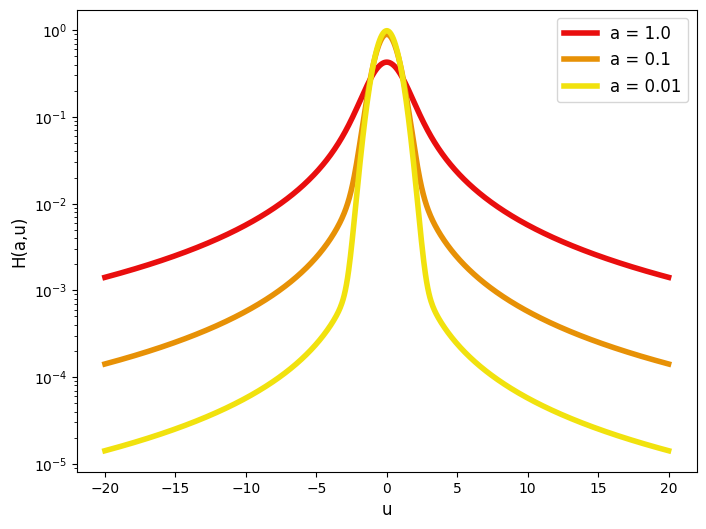

In [78]:
u = np.linspace(-20, 20, 1000)
a = [1.0, 0.1, 0.01]
fig, ax = plt.subplots(1,1,figsize = (8,6))
for val1 in a: 
    inte = []
    for val2 in u: 
        inte.append(integrate_voigt_profile(val1, val2))
    ax.plot(u, inte, linewidth = 4, label = f"a = {val1}")     
ax.set_yscale('log')  
ax.legend(loc = 'upper right', fontsize = 12)
ax.set_xlabel("u", fontsize = 12)
ax.set_ylabel("H(a,u)", fontsize = 12)
plt.savefig("parta.png", dpi=300)
#plt.savefig("parta.pdf", dpi=300)

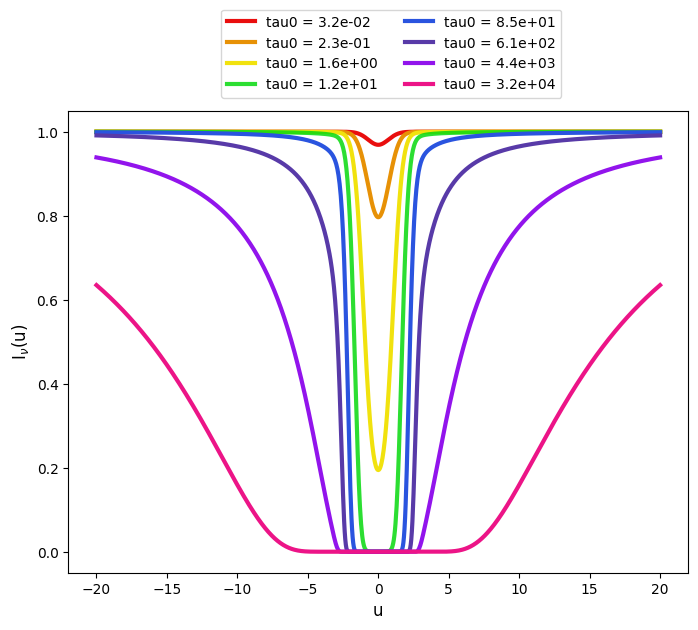

In [95]:
tau0 = np.logspace(-1.5, 4.5, 8)
a = 0.01 
H0 = integrate_voigt_profile(a, 0)
fig, ax =plt.subplots(1,1, figsize = (8,6))
for t in tau0: 
    inte = []
    for val in u: 
        int = integrate_voigt_profile(a, val)
        I = np.exp(-t * int/H0)
        inte.append(I)
    ax.plot(u, inte, label = f"tau0 = {t:.1e}", linewidth = 3)
fig.legend(bbox_to_anchor=(0.75,1.06), ncol = 2)
ax.set_xlabel("u", fontsize = 12)
ax.set_ylabel(r"I$_\nu$(u)", fontsize = 12)
#plt.savefig("figures/part2c.png", dpi = 300, bbox_inches = 'tight')
plt.savefig("figures/part2c.pdf", dpi = 300, bbox_inches = 'tight')
    

In [204]:
Umax = 1.0e4                
N_u   = 200000             
u = np.linspace(-Umax, Umax, N_u)
a = 1.3e-4
tau0 = np.logspace(-2, 10, 600)
H = np.empty_like(u)
for i, val in enumerate(u): 
    H[i]=(integrate_voigt_profile(a, val))



In [205]:
W = np.empty_like(tau0)
for i, t in enumerate(tau0):
    # Optical depth as a function of frequency
    tau_u = t * H / H0          # Eq. (5) in the analysis
    # Residual intensity (1 – e^{-τ})
    residual = 1.0 - np.exp(-tau_u)
    # Equivalent width (in Doppler‑width units)
    W[i] = np.trapezoid(residual, u) 

Text(0, 0.5, 'Equivalent Width')

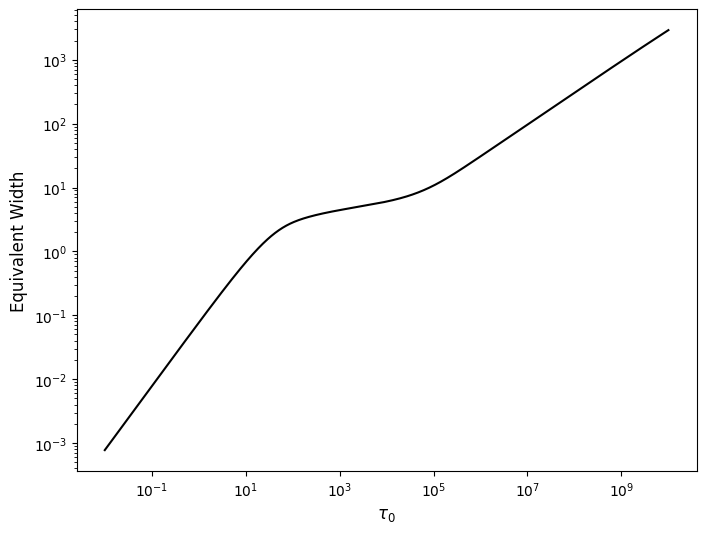

In [206]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(tau0, W, color = 'k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r"$\tau_0$", fontsize = 12)
ax.set_ylabel("Equivalent Width", fontsize = 12)
#plt.savefig("figures/partd.png", dpi = 300)
#plt.savefig("figures/partd.pdf", dpi = 300)